# Evaluierung LLM-as-a-Judge

Evaluierung mittels LLM-as-a-judge erfolgt unter Verwendung des AutoRubric-Frameworks.

Autorubric: AUnifiedFrameworkforRubric-BasedLLMEvaluation  
https://arxiv.org/pdf/2603.00077v1

**Voraussetzungen**

Environment: autorubric

Zur Durchführung der Evaluierung müssen die Antworten zu den Fragen aus dem Datensatz durch die Sprachmodelle erzeugt werden (query_baseline.ipynb bzw. query_retrieval.ipynb).

**Versuchsaufbau**

Unter Verwendung der Segmentierungsverfahren Sliding-Window mit einer Fenstergröße von 512 Zeichen sowie dem MLM-Klassifikationsmodell und Überlappungen von jeweils 50%, wurde für die durch die beiden Sprachmodelle zu den 397 gewählten Fragen generierten Antworten die höchste durchschnittliche Ähnlichkeit mittels Vector-Similarity berechnet.

Für diese Antworten wird eine Evaluierung mit Hilfe der Methode LLM-as-a-Judge durchgeführt. Die Bewertung der Modell-Antworten erfolgt dabei paarweise mit den dazugehörigen Referenz-Antworten aus dem Datensatz und es wird eine Single-Judge-Strategie angewendet, wobei die Evaluierung jeweils durch 2 unabhängige Judges erfolgt und ein Vergleich zwischen diesen durchgeführt wird.

Kern der Bewertung ist die Prüfung der Korrektheit, Vollständigkeit und Konsistenz der Modell-Antworten und für die Untersuchung werden entsprechende objektiv bewertbare Kriterien verwendet und keine subjektiven Aspekte wie z.B. die Klarheit der Formulierung oder Nützlichkeit der Antwort betrachtet. Die Korrektheit und Konsistenz ist entweder gegeben oder nicht, die Vollständigkeit wird als qualitatives Kriterium operationalisiert und die inhaltliche Abdeckung in Form ordinaler Stufen beurteilt. Es werden insgesamt zwei binäre sowie ein ordinales Kriterium definiert.

```
rubric = Rubric.from_dict([
    {'weight': 5.0, 'requirement': 'Is the question answered factually correctly based on the reference answer?'},
    {'weight': 5.0, 'requirement': 'Compared to the reference answer, the model answer contains no internal contradictions.'},
    {
        'weight': 10.0,
        'requirement': 'Does the model answer cover all factual information relative to the reference answer? The absence of a single piece of information is considered a failure to meet the criterion.',
        'scale_type': 'ordinal',
        'options': [
            {'label': 'The model answer does not contain any of the information.', 'value': 0.0},
            {'label': 'The model answer contains at least one piece of information.', 'value': 0.5},
            {'label': 'The model answer contains all the information.', 'value': 1.0},
        ]
    },
])
```

Die Methode LLM-as-a-Judge stellt einen Ansatz zur automatisierten Evaluierung der Ausgaben generativer Sprachmodelle bzw. von Texten im Allgemeinen dar, bei der die Fähigkeiten von LLMs zur Verarbeitung natürlicher Sprache für die Bewertung komplexer Eigenschaften genutzt werden. Anstelle des Vergleichs der lexikalischen oder semantischen Ähnlichkeit mit einer Referenz-Antwort erfolgt die Evaluierung dabei in strukturierter Form auf Grundlage eines Kriterien-Katalogs, auch Rubric genannt, über welchen zu bewertende Eigenschaften in Bezug auf einen Text spezifiziert werden.

Wie für den Vergleich mittels Vector-Similarity ist es mit der Methode LLM-as-a-Judge möglich eine große Anzahl an Texten automatisiert zu bewertet. Einen Vorteil demgegenüber stellt deren hohe Flexibilität aufgrund der Formulierung von Anforderungen in natürlicher Sprache dar. Sie eignet sich besonders für offen formulierte Aufgaben und die Prüfung vielfältiger Merkmale wie der Vollständigkeit, Korrektheit, Kohärenz, Konsistenz oder Instruktionsbefolgung etc., welche über einen reinen Vergleich von Ähnlichkeiten hinausgehen und für die der Einsatz von Metriken wie BLEU, ROUGE und METEOR aufgrund ihrer mangelnden semantischen und kontextuellen Fähigkeiten sowie geringen Übereinstimmung mit menschlichen Bewertungen grundsätzlich nicht geeignet ist.

In einfacher Form kann die Evaluierung als Gesamt-Bewertung der Qualität einer Ausgabe durchgeführt werden, z.B. über die Definition von Niveaustufen 1 (sehr gut), 2 (gut), 3 (befriedigend), 4 (ausreichend) und 5 (mangelhaft) mit einer entsprechenden Beschreibung der zu erfüllenden Anforderungen für die jeweilige Stufe. Vorteil dieser Lösung ist die einfache Anwendung aber sie beinhaltet nur wenige Informationen für eine detaillierte Analyse.

Eine Unterteilung in einzelne, voneinander unabhängige Kriterien ermöglicht eine tiefergehende Analyse der Ausprägung verschiedener Aspekte und deren Beitrag zu einer Bewertung. In Abhängigkeit des zu bewertenden Aspekts können unterschiedliche Kriterien-Typen, binär, nominal oder ordinal, eingesetzt werden. Ein binäres Kriterium ist im Ergebnis entweder erfüllt oder nicht erfüllt, beispielsweise ob ein Text orthografische Fehler enthält oder nicht.

Mit Hilfe nominaler Kriterien können kategoriale Ausprägungen definiert werden, welche eine qualitative Aussage in Bezug auf ein Merkmal treffen. Sie dienen der Klassifizierung oder Kategoriesierung, wobei die Kategorien gleichwertig nebeneinander stehen, keine ist besser oder höher und es besteht keine natürliche Rangfolge oder mathematische Ordnung zwischen ihnen, z.B. Toxizität von Texten (beleidigend, hate speech, gewaltverherrlichend, sicher).

Ordinale Kriterien bestehen aus einer Reihe geordneter Level, welche eine abgestufte Bewertung ermöglichen und auf diese Weise Auskunft über die Qualität eines Merkmals geben, z.B. die Gesamt-Qualität einer Antwort von 1 (sehr gut) bis 5 (ungenügend). Bei der Wahl dieses Kriterientyps ist zu beachten, dass die Abgrenzung zwischen den Stufen durch verschiedene Bewerter unterschiedlich erfolgen kann. Des Weiteren wurde beobachtet, dass bei Verwendung großer Skalen tendenziell Werte nahe der Mitte gewählt werden und es wir die Verwendung kleiner Skalen empfohlen.

Mögliche Kriterien können sehr vielfältig sein und sich je nach Aufgaben-Typ stark unterscheiden. Um eine zuverlässige Messbarkeit sowie eindeutige und korrekte Interpretation zu gewährleisten, müssen die durch LLMs zu bewertenden Kriterien operationalisiert und präzise formuliert werden. Des Weiteren sollten sie atomar, unabhängig und deterministisch bewertbar sein, sich nicht gegenseitig überschneiden und klar trennbare Entscheidungsgrenzen besitzen.

Die Evaluierung kann in verschiedenen Modi und unter Anwendung verschiedener Strategien durchgeführt werden, wobei die Modi durch die Informationen bestimmt sind, welche für die Bewertung zur Verfügung gestellt werden und wie die Bewertung aufgebaut ist.

Die Bewertung einer Ausgabe kann punktweise oder paarweise erfolgen. Bei der punktweisen Bewertung wird eine einzelne Ausgabe in Verbindung mit der zugrundeliegenden Eingabe betrachtet. Bei der paarweisen Bewertung wird zusätzlich eine zweite Ausgabe oder Referenz einbezogen und ein Vergleich in unterschiedlicher Form zwischen diesen durchgeführt, z.B. hinsichtlich Qualität oder Übereinstimmung. Die paarweise Bewertung ist geeignet, wenn eine absolute Aussage nicht möglich oder schwierig ist und ein relativer Vergleich gezogen werden muss. Vorteil einer punktweisen Bewertung ist der geringere Rechenaufwand, welcher mit der Anzahl der zu prüfenden Ausgaben linear wächst, wohingegen das Wachstum bei paarweisen Bewertungen quadratisch ist und damit zu einem höheren Verbrauch an Token führt.

Mögliche Strategien für die Durchführung der Evaluierung sind der Einsatz eines Single-Judge oder Multi-Judge-Ensembles. Bei der Multi-Judge Evaluierung wird die Bewertung der einzelnen Ausgaben durch mehrere unabhängige LLMs durchgeführt und die Ergebnisse über Mehrheitsentscheidungen, Gewichtungen, Einstimmigkeit oder die Auswahl einer beliebigen Abstimmung aggregiert.

## Setup

### Pakete laden

In [1]:
import config

import os
import json

import numpy as np
import pandas as pd

import pyarrow as pa
import pyarrow.parquet as pq

import scipy.stats as stats

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from autorubric import Rubric, Criterion, LLMConfig, DataItem, RubricDataset, evaluate, EvalRunner, EvalConfig, EvalResult
from autorubric.graders import CriterionGrader
from autorubric.meta import evaluate_rubric_standalone

%env APPHUBAI_API_KEY=
%env LOCAL_API_KEY=c017TkMCsbF

env: APPHUBAI_API_KEY=
env: LOCAL_API_KEY=c017TkMCsbF


In [ ]:
# Konfiguration AutoRubric

# AutoRubric verwendet für die Verwaltung der Anfragen an die Judge-LLM das Paket litellm
# Die verwendeten LLM-Provider müssen über die Konfiguration in der Datei llms\openai_like\providers.json bekanntgemacht werden
# apphubai.wolke.uni-greifswald.de muss als Provider der Datei hinzugefügt werden

#import litellm, os
#print(os.path.join(os.path.dirname(litellm.__file__), 'llms', 'openai_like', 'providers.json'))
##C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\litellm\llms\openai_like\providers.json

# Eintrag zu Datei provider.json hinzufügen
#"apphubai": {
#    "base_url": "https://apphubai.wolke.uni-greifswald.de/v1",
#    "api_key_env": "APPHUBAI_API_KEY"
#}

### Variablen+Funktionen

In [2]:
# Segmentierungsverfahren für Retrieval
retrieval = [
    'block-size512_overlap0.5',
    'classification_overlap0.5'
]

# Farbwerte für Plots
model_colors = ['#B6B7F7', '#E9AFA2']

### Sample

Funktion zur Ausgabe der Daten für eine Beispiel-Frage mit Modell-/ und Referenz-Antwort für ein Generator-LLM, ein Segmentierungsverfahren und der Ergebnisse der Evaluierung durch ein Judge-LLM

In [3]:
def get_sample(index, model_select, judge_model_select, retrieval_select):
    # gewähltes Generator-LLM
    model_name = config.models['generation'][model_select][config.models['generation'][model_select].index('/') + 1:]
    
    # gewähltes Judge-LLM
    judge_model_name = config.models['judge'][judge_model_select][config.models['judge'][judge_model_select].index('/') + 1:config.models['judge'][judge_model_select].index(':')]
    
    # Ergebnisse der Evaluierung für Generator-LLM und Judge-LLM laden
    result = EvalResult.from_experiment(f'./rag-eval/{model_name}_retrieval_{retrieval[retrieval_select]}_{judge_model_name}')
    
    # Modell-Antworten laden
    answers_model = pq.read_table(f'{config.dataset["path"]}answers_model_{model_name}_retrieval_{retrieval[retrieval_select]}.parquet').to_pandas()
    
    print(f'index: {index}')
    print(f'---\ngenerator model: {model_name}')
    print(f'---\njudge model: {judge_model_name}')
    print(f'---\nretrieval: {retrieval[retrieval_select]}')
    print('---\nquery\n')
    #print(queries_answers_select.loc[answer_len_diff_abs_index].iloc[index]['query'])
    print(queries_text_text_table_select.loc[index]['query'])
    print('---\nanswer reference\n')
    print(queries_text_text_table_select.loc[index]['answer'])
    print(f'---\nanswer model\n')
    #print(answers_model.loc[queries_text_text_table_select.iloc[index].name]['answer_model'])
    print(answers_model.loc[index, 'answer_model'])
    print('---\nanswer similarity\n')
    print(answers_model.loc[index, 'answer_similarity'])
    
    #file = open(f'{config.dataset["path"]}corpus/{qrels.loc[queries_text_text_table_select.iloc[index].name]['doc_id']}.json', 'r')
    #data = json.load(file)
    #file.close()
    
    #print('\nground truth\n')
    #print(data['sections'][qrels.loc[queries_text_text_table_select.iloc[index].name]['section_id']]['text'])
    
    item = result.item_results[queries_text_text_table_select.index.get_loc(index)]
        
    print(f'---\ndescription: {item.item.description}\n')
    print(f'---\nscore: {item.report.score}' if item.report.score is not None else '\nScore: n/a (grade failed)')
    
    print(f'\nKriterien\n')
    
    for criterion in item.report.report:
        verdict = 'n/a'
        # `final_verdict` is None on error/multi-choice criteria; guard before printing.
        if criterion.final_multi_choice_verdict is not None:
            verdict = criterion.final_multi_choice_verdict.value
        elif criterion.final_verdict is not None:
            verdict = criterion.final_verdict.value
        
        print(f'[{verdict}] {criterion.criterion.requirement}')
        print(f'Reason: {criterion.final_reason}')

### Daten laden

Fragen, Antworten und PDF-URLs aus Datensatz laden

In [4]:
# Answers
answers = pd.read_json(f'{config.dataset["path"]}answers.json', orient='index', dtype_backend='numpy_nullable').rename(columns={0: "answer"})
# Queries
queries = pd.read_json(f'{config.dataset["path"]}queries.json', orient='index', dtype_backend='numpy_nullable')
# Relations
qrels = pd.read_json(f'{config.dataset["path"]}qrels.json', orient='index', dtype_backend='numpy_nullable')

# PDF URLs
#pdf_urls = pd.read_json(f'{config.dataset["path"]}pdf_urls.json', orient='index', dtype_backend='numpy_nullable').rename(columns={0: "pdf_urls"})

pdf_urls_clean = pd.read_json(f'{config.dataset["path"]}pdf_urls_clean.json', orient='index', dtype_backend='numpy_nullable')#.rename(columns={0: "pdf_urls"})
pdf_urls = pdf_urls_clean.loc[pdf_urls_clean.values]

### Fragen selektieren

Fragen mit Quelle "Text" und "Text-Tabelle" und mindestens acht Wörtern in der Referenz-Antwort (Fragen mit kurzen Antworten wie "yes" ausschließen) für Ausführung selektieren

In [5]:
# Fragen und Antworten über Index joinen
queries_answers = queries.merge(answers, how='inner', left_index=True, right_index=True)

# Anzahl Wörter der Fragen 
queries_answers['answer_replace'] = queries_answers['answer'].str.replace(r'\p{P}+', '', regex=True).str.replace(r'[\n\t\s]+', ' ', regex=True)
queries_answers['answer_word_count'] = queries_answers['answer_replace'].str.split(' ').str.len()

# Fragen mit source=text|text-table und answer_word_count>=8
queries_text_text_table = queries_answers.loc[((queries_answers['source'] == 'text') | (queries_answers['source'] == 'text-table')) & (queries_answers['answer_word_count'] >= 8)]#.sample(n=samples, axis=0, random_state=42)

# 1/4 der Fragen selektieren
queries_text_text_table = queries_text_text_table.sample(n=round(queries_text_text_table.shape[0] / 4), axis=0, random_state=42)

In [6]:
# Fragen ausschließen, welche sich auf ausgeschlossene Dokumente beziehen

# Beziehung zwischen Frage und Dokument über qrels
# qrels/Dokumente für alle Fragen wählen
qrels_select = qrels.loc[queries_text_text_table.index]
# qrels ausschließen, für die Dokumente (doc_id) nicht in pdf_urls (index)
qrels_select = qrels.loc[qrels_select.loc[~qrels_select['doc_id'].isin(pdf_urls.index)].index]

queries_text_text_table_select = queries_text_text_table.loc[~queries_text_text_table.index.isin(qrels_select.index)]

### Rubric-Definition

Kriterien-Katalog definieren

In [7]:
# Rubric Kriterien definieren
rubric = Rubric.from_dict([
    {'weight': 5.0, 'requirement': 'Is the question answered factually correctly based on the reference answer?'},
    {'weight': 5.0, 'requirement': 'Compared to the reference answer, the model answer contains no internal contradictions.'},
    {
        'weight': 10.0,
        'requirement': 'Does the model answer cover all factual information relative to the reference answer? The absence of a single piece of information is considered a failure to meet the criterion.',
        'scale_type': 'ordinal',
        'options': [
            {'label': 'The model answer does not contain any of the information.', 'value': 0.0},
            {'label': 'The model answer contains at least one piece of information.', 'value': 0.5},
            {'label': 'The model answer contains all the information.', 'value': 1.0},
        ]
    },
])

## Rubric-Quality

Prüfung der Qualität der definierten Kriterien.

Durch das Paket AutoRubric werden Funktionen zur Durchführung einer Meta-Evaluierung des Rubrics zur Verfügung gestellt.

https://autorubric.org/docs/api/meta/

In [16]:
# gewähltes Generator-LLM
model_select = 1

# gewähltes Judge-LLM
judge_model_select = 0

# LLM-Judge konfigurieren
llm_config = LLMConfig(
    #model=f'local/{config.models['generation'][1 - model_select]}',
    model=f'apphubai/{config.models['judge'][judge_model_select]}',
    temperature=0.1,
    #cache_enabled=True,
    max_parallel_requests=2
)

result = await evaluate_rubric_standalone(
    rubric,
    llm_config,
    display="stdout"
)

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Standalone Evaluation (rubric quality in isolation)                                                             │
│                                                                                                                 │
│ Evaluating rubric with 3 criteria                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────────── Results ────────────────────────────────────────────────────╮
│   Score        0.87                                                                                             │
│   Raw Score    90.00                                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

           Clarity & Precision           
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Criterion           ┃ Status ┃ Weight ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ clear_requirements  │  MET   │  +10.0 │
│ specific_actionable │  MET   │  +10.0 │
│ unidimensional      │  MET   │  +10.0 │
│ behavioral_language │  MET   │   +8.0 │
└─────────────────────┴────────┴────────┘

           Structure & Design            
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Criterion           ┃ Status ┃ Weight ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ reasonable_count    │  MET   │   +6.0 │
│ balanced_weights    │  MET   │   +6.0 │
│ orthogonal_criteria │  MET   │   +8.0 │
└─────────────────────┴────────┴────────┘

               LLM-Friendliness               
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Criterion                ┃ Status ┃ Weight ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ independently_verifiable │  MET   │  +10.0 │
│ objective_assessable     │  MET   │   +8.0 │
│ well_defined_options     │  MET   │   +6.0 │
└──────────────────────────┴────────┴────────┘

...

                Anti-Patterns                
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┓
┃ Criterion             ┃  Status  ┃ Weight ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━┩
│ double_barreled       │  CLEAR   │   -8.0 │
│ vague_wording         │  CLEAR   │   -8.0 │
│ circular_tautological │  CLEAR   │   -6.0 │
│ excessive_overlap     │  CLEAR   │   -6.0 │
│ overly_verbose        │  CLEAR   │   -6.0 │
│ hedging_language      │  CLEAR   │   -6.0 │
│ generic_boilerplate   │ DETECTED │   -8.0 │
└───────────────────────┴──────────┴────────┘

            LLM-Judge Anti-Patterns            
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┓
┃ Criterion               ┃  Status  ┃ Weight ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━┩
│ no_negative_criteria    │ DETECTED │   -6.0 │
│ unfalsifiable_criteria  │  CLEAR   │   -8.0 │
│ boundary_ambiguity      │  CLEAR   │   -8.0 │
│ verbosity_rewarding     │  CLEAR   │   -6.0 │
│ poorly_anchored_ordinal │  CLEAR   │   -6.0 │
│ counting_dependent      │  CLEAR   │   -4.0 │
└─────────────────────────┴──────────┴────────┘

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Issues Found                                                                                                    │
╰──────────────────────────────────────── Feedback for rubric improvement ────────────────────────────────────────╯

╭────────────────────────────────────── generic_boilerplate (Anti-Patterns) ──────────────────────────────────────╮
│ default: The criteria are generic quality checks (factual correctness, internal contradictions, and coverage)   │
│ that could apply to any Q&A task and are not tailored to a specific subject or domain. [Affects: #1, #2, #3]    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────── no_negative_criteria (LLM-Judge Anti-Patterns) ─────────────────────────────────╮
│ default: The rubric contains only positive weights (5.0, 5.0, and 10.0) and lacks any negative-weight or        │
│ penalty criteria.                                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Parameter-Test

Durchführung eines Tests der Sampling-Methode temperature mit Parameter-Werten im Bereich von 0.0-0.4 mit einer Stichprobe von 30 der 397 gewählten Fragen.

Generator-LLM: mistralai/Ministral-8B-Instruct-2410  
Segmentierung Retrieval: classification_overlap0.5
Judge-LLMs: unsloth/gemma-4-31B-it-qat-GGUF:UD-Q4_K_XL', unsloth/Qwen3.6-35B-A3B-GGUF:UD-Q4_K_XL

In [ ]:
# gewähltes Generator-LLM
model_select = 0
model_name = config.models['generation'][model_select][config.models['generation'][model_select].index('/') + 1:]

# Segmentierung für Retrieval
retrieval_select = 1

# Modell-Antworten laden
answers_model = pq.read_table(f'{config.dataset["path"]}answers_model_{model_name}_retrieval_{retrieval[retrieval_select]}.parquet').to_pandas()

# gewähltes Judge-LLM
judge_model_select = 1
judge_model_name = config.models['judge'][judge_model_select][config.models['judge'][judge_model_select].index('/') + 1:config.models['judge'][judge_model_select].index(':')]

# Datensatz erstellen
dataset_test = RubricDataset(
    rubric=rubric
)

# Test sample
samples = 30

# Einträge zum Datensatz hinzufügen
for i in range(samples):
    # struktuierte Dokument-Daten aus Korpus laden
    #file = open(f'{config.dataset["path"]}corpus/{qrels.loc[queries_text_text_table_select.iloc[i].name]['doc_id']}.json', 'r')
    #data = json.load(file)
    #file.close()
    
    dataset_test.add_item(
        description=f'answer {queries_text_text_table_select.iloc[i].name}',
        submission=answers_model.loc[queries_text_text_table_select.iloc[i].name]['answer_model'], 
        reference_submission=queries_text_text_table_select.iloc[i]['answer'],
        #ground_truth=[
        #    data['sections'][qrels.loc[queries_text_text_table_select.iloc[i].name]['section_id']]['text'],
        #    data['sections'][qrels.loc[queries_text_text_table_select.iloc[i].name]['section_id']]['text'],
        #    data['sections'][qrels.loc[queries_text_text_table_select.iloc[i].name]['section_id']]['text']
        #],
        prompt=queries_text_text_table_select.iloc[i]['query']
    )

# Verzeichnis für Speicherung des Datensatz prüfen+anlegen
#if not os.path.exists('./rag-eval'):
#    os.mkdir('./rag-eval')

# Datensatz speichern
#dataset_test.to_file('./rag-eval/dataset-test.json')

# Datensatz laden
#dataset_test = RubricDataset.from_file('./rag-eval/dataset-test.json')

# temperature#
#for i in range(5):
#temp = i / 10

temp = 0.4

# LLM-Judge konfigurieren
llm_config = LLMConfig(
    #model=f'local/{config.models['generation'][1 - model_select]}',
    model=f'apphubai/{config.models['judge'][judge_model_select]}',
    temperature=temp,
    #cache_enabled=True,
    max_parallel_requests=1,
    retry_min_wait=2,
    retry_max_wait=5
)

grader = CriterionGrader(
    llm_config=llm_config,
    #aggregation='weighted',#unanimous#weighted#any
    #system_prompt="Users posed questions on various topics and areas related to scientific publications, and a large language model generated answers to them. The task involves evaluating the language model's output. To this end, various binary and ordinal criteria were defined to assess the quality of aspects such as the correctness, consistency und completeness of the generated answers. The ordinal criteria include a set of options indicating the degree of alignment; when evaluating a specific aspect, the option that best describes it must be selected.",
)

# Evaluation-Runner Konfiguration
eval_config = EvalConfig(
    experiment_name=f'{model_name}_retrieval_{retrieval[retrieval_select]}_{judge_model_name}_temp-{temp}',
    experiments_dir='./rag-eval',
    max_concurrent_items=1,
    show_progress=True,
)

runner = EvalRunner(dataset=dataset_test, grader=grader, config=eval_config)
result = await runner.run()

### Stats

Statistische Kennzahlen zu Ergebnissen des Parameter-Test

In [ ]:
# Daten laden

# Test sample
samples = 30

# Segmentierung für Retrieval
retrieval_select = 1

# Dictionary mit Ergebnissen
data = {'generator-model': [], 'judge-model': [], 'temp': [], 'scores': []}

#temperature
for t in range(5):
    temp = t / 10
    # Generator-Modell
    for g in [0]:
        g_m = config.models['generation'][g][config.models['generation'][g].index('/') + 1:]
        # Judge-Modell
        for j in [0, 1]:
            j_m = config.models['judge'][j][config.models['judge'][j].index('/') + 1:config.models['judge'][j].index(':')]
            # Datei mit Ergebnissen laden
            result = EvalResult.from_experiment(f'./rag-eval/{g_m}_retrieval_{retrieval[retrieval_select]}_{j_m}_temp-{temp}')
            # Daten zu Dictionary hinzufügen
            data['generator-model'].extend([g_m] * samples)
            data['judge-model'].extend([j_m] * samples)
            data['temp'].extend([temp] * samples)
            data['scores'].extend([item.report.score for item in result.item_results if item.report.score is not None])

df = pd.DataFrame.from_dict(data)

In [8]:
df.groupby(by=['generator-model', 'judge-model', 'temp'])['scores'].describe()#agg(['count', 'mean', 'min', 'max', 'std', 'median'])

count      mean  \
generator-model            judge-model             temp                    
Ministral-8B-Instruct-2410 Qwen3.6-35B-A3B-GGUF    0.0    30.0  0.925000   
                                                   0.1    30.0  0.891667   
                                                   0.2    30.0  0.891667   
                                                   0.3    30.0  0.875000   
                                                   0.4    30.0  0.875000   
                           gemma-4-31B-it-qat-GGUF 0.0    30.0  0.933333   
                                                   0.1    30.0  0.933333   
                                                   0.2    30.0  0.941667   
                                                   0.3    30.0  0.933333   
                                                   0.4    30.0  0.933333   

                                                              std   min  \
generator-model            judge-model             temp                   
Ministral-8B-Instruct-2410 Qwen3.6-35B-A3B-GGUF    0.0   0.198594  0.25   
                                                   0.1   0.224409  0.25   
                                                   0.2   0.224409  0.25   
                                                   0.3   0.234429  0.25   
                                                   0.4   0.252146  0.00   
                           gemma-4-31B-it-qat-GGUF 0.0   0.130208  0.50   
                                                   0.1   0.130208  0.50   
                                                   0.2   0.126002  0.50   
                                                   0.3   0.130208  0.50   
                                                   0.4   0.130208  0.50   

                                                            25%  50%  75%  max  
generator-model            judge-model             temp                         
Ministral-8B-Instruct-2410 Qwen3.6-35B-A3B-GGUF    0.0   1.0000  1.0  1.0  1.0  
                                                   0.1   1.0000  1.0  1.0  1.0  
                                                   0.2   1.0000  1.0  1.0  1.0  
                                                   0.3   0.8125  1.0  1.0  1.0  
                                                   0.4   0.8125  1.0  1.0  1.0  
                           gemma-4-31B-it-qat-GGUF 0.0   1.0000  1.0  1.0  1.0  
                                                   0.1   1.0000  1.0  1.0  1.0  
                                                   0.2   1.0000  1.0  1.0  1.0  
                                                   0.3   1.0000  1.0  1.0  1.0  
                                                   0.4   1.0000  1.0  1.0  1.0

## Test-Evaluierung

Test der Evaluierung anhand eines Beispiels

In [11]:
# gewähltes Generator-LLM
model_select = 1
model_name = config.models['generation'][model_select][config.models['generation'][model_select].index('/') + 1:]

# gewähltes Judge-LLM
judge_model_select = 0

# LLM-Judge konfigurieren
llm_config = LLMConfig(
    #model=f'local/{config.models['generation'][1 - model_select]}',
    model=f'apphubai/{config.models['judge'][judge_model_select]}',
    temperature=0.1,
    #cache_enabled=True,
    max_parallel_requests=2
)

grader = CriterionGrader(
    llm_config=llm_config,
    #aggregation='weighted',#unanimous#weighted#any
    #system_prompt="Users posed questions on various topics and areas related to scientific publications, and a large language model generated answers to them. The task involves evaluating the language model's output. To this end, various binary and ordinal criteria were defined to assess the quality of aspects such as the correctness, consistency und completeness of the generated answers. The ordinal criteria include a set of options indicating the degree of alignment; when evaluating a specific aspect, the option that best describes it must be selected.",
)

# Segmentierung für Retrieval
retrieval_select = 1

# Modell-Antworten laden
answers_model = pq.read_table(f'{config.dataset["path"]}answers_model_{model_name}_retrieval_{retrieval[retrieval_select]}.parquet').to_pandas()

# Sample-Index
index = 0

# Evaluierung durchführen
result = await rubric.grade(
    to_grade=answers_model.loc[queries_text_text_table_select.iloc[index].name]['answer_model'],
    grader=grader,
    query=queries_text_text_table_select.iloc[index]['query'],
    reference_submission=queries_text_text_table_select.iloc[index]['answer']
)

# Ergebnisse ausgeben
print(f'Score: {result.score:.2f}' if result.score is not None else 'Score: n/a (grade failed)')

for criterion in result.report:
    verdict = 'n/a'
    # `final_verdict` is None on error/multi-choice criteria; guard before printing.
    if criterion.final_multi_choice_verdict is not None:
        verdict = criterion.final_multi_choice_verdict.value
    elif criterion.final_verdict is not None:
        verdict = criterion.final_verdict.value
    
    print(f'[{verdict}] {criterion.criterion.requirement}')
    print(f'Reason: {criterion.final_reason}')

Score: 0.75
[MET] Is the question answered factually correctly based on the reference answer?
Reason: default: The submission correctly answers 'Yes' (implicitly by stating he is affiliated) and confirms the association with Deep Bio Inc., which aligns with the factual core of the reference answer.
[MET] Compared to the reference answer, the model answer contains no internal contradictions.
Reason: default: The submission is consistent throughout, stating that Tae-Yeong Kwak is affiliated with Deep Bio Inc. and providing supporting evidence (Research Team role and email address) without any contradictory claims.
[0.5] Does the model answer cover all factual information relative to the reference answer? The absence of a single piece of information is considered a failure to meet the criterion.
Reason: default: The model answer confirms the association with Deep Bio Inc. (which is in the reference), but it fails to mention that he serves as CTO, instead stating he is part of the Research

## Evaluierung

Evaluierung der durch die beiden LLMs generierten Antworten zu den 397 gewählten Fragen durch beide Judge-LLMs

### Datensatz erstellen

Datensatz für Evaluierung erstellen

In [ ]:
"""# gewähltes Generator-LLM
model_select = 0
model_name = config.models['generation'][model_select][config.models['generation'][model_select].index('/') + 1:]

# Segmentierung für Retrieval
retrieval_select = 1

#retrieval = f'block-size512_overlap0.5'
retrieval = 'classification_overlap0.5'
#retrieval = 'baseline'

# Modell-Antworten laden
answers_model = pq.read_table(f'{config.dataset["path"]}answers_model_{model_name}_retrieval_{retrieval[retrieval_select]}.parquet').to_pandas()

# Datensatz erstellen
dataset = RubricDataset(
    rubric=rubric
)

# Einträge zum Datensatz hinzufügen
for i in range(queries_text_text_table_select.shape[0]):
    # struktuierte Dokument-Daten aus Korpus laden
    #file = open(f'{config.dataset["path"]}corpus/{qrels.loc[queries_text_text_table_select.iloc[i].name]['doc_id']}.json', 'r')
    #data = json.load(file)
    #file.close()
    
    dataset.add_item(
        description=f'answer {queries_text_text_table_select.iloc[i].name}',
        submission=answers_model.loc[queries_text_text_table_select.iloc[i].name]['answer_model'], 
        reference_submission=queries_text_text_table_select.iloc[i]['answer'],
        #ground_truth=[
        #    data['sections'][qrels.loc[queries_text_text_table_select.iloc[i].name]['section_id']]['text'],
        #    data['sections'][qrels.loc[queries_text_text_table_select.iloc[i].name]['section_id']]['text'],
        #    data['sections'][qrels.loc[queries_text_text_table_select.iloc[i].name]['section_id']]['text']
        #],
        prompt=queries_text_text_table_select.iloc[i]['query']
    )

# Verzeichnis für Speicherung des Datensatz prüfen+anlegen
if not os.path.exists('./rag-eval'):
    os.mkdir('./rag-eval')

# Datensatz speichern
dataset.to_file('./rag-eval/dataset.json')"""

### Ausführung

Ausführung der Evaluierung mittels EvalRunner

Kriterien-Katalog auf generierte Antworten durch LLMs für gewählte 397 Fragen aus dem Datensatz anwenden

In [ ]:
# gewähltes Generator-LLM
model_select = 0
model_name = config.models['generation'][model_select][config.models['generation'][model_select].index('/') + 1:]

# Segmentierung für Retrieval
retrieval_select = 1

# Modell-Antworten laden
answers_model = pq.read_table(f'{config.dataset["path"]}answers_model_{model_name}_retrieval_{retrieval[retrieval_select]}.parquet').to_pandas()

###
# Datensatz erstellen
###
dataset = RubricDataset(
    rubric=rubric
)

# Einträge zum Datensatz hinzufügen
for i in range(queries_text_text_table_select.shape[0]):
    
    dataset.add_item(
        description=f'answer {queries_text_text_table_select.iloc[i].name}',
        submission=answers_model.loc[queries_text_text_table_select.iloc[i].name]['answer_model'], 
        reference_submission=queries_text_text_table_select.iloc[i]['answer'],
        prompt=queries_text_text_table_select.iloc[i]['query']
    )

# gewähltes Judge-LLM
judge_model_select = 1
judge_model_name = config.models['judge'][judge_model_select][config.models['judge'][judge_model_select].index('/') + 1:config.models['judge'][judge_model_select].index(':')]

# LLM-Judge konfigurieren
llm_config = LLMConfig(
    #model=f'local/{config.models['generation'][1 - model_select]}',
    model=f'apphubai/{config.models['judge'][judge_model_select]}',
    temperature=0.1,
    #cache_enabled=True,
    max_parallel_requests=1,
    retry_min_wait=2,
    retry_max_wait=5
)

grader = CriterionGrader(
    llm_config=llm_config,
    #aggregation='weighted',#unanimous#weighted#any
    #system_prompt="Users posed questions on various topics and areas related to scientific publications, and a large language model generated answers to them. The task involves evaluating the language model's output. To this end, various binary and ordinal criteria were defined to assess the quality of aspects such as the correctness, consistency und completeness of the generated answers. The ordinal criteria include a set of options indicating the degree of alignment; when evaluating a specific aspect, the option that best describes it must be selected.",
)

# Datensatz laden
#dataset = RubricDataset.from_file('./rag-eval/dataset.json')

###
# Evaluierung
###
"""result = await evaluate(dataset, grader, show_progress=True)

print(f"Evaluated {result.successful_items}/{result.total_items}")
print(f"Throughput: {result.timing_stats.items_per_second:.2f} items/s")
print(f"Total cost: ${result.total_completion_cost or 0:.4f}")"""

# Evaluation-Runner Konfiguration
eval_config = EvalConfig(
    experiment_name=f'{model_name}_retrieval_{retrieval[retrieval_select]}_{judge_model_name}',
    experiments_dir='./rag-eval',
    max_concurrent_items=1,
    show_progress=True,
)

runner = EvalRunner(dataset=dataset, grader=grader, config=eval_config)
result = await runner.run()

# Resume
#runner = EvalRunner(dataset=dataset, grader=grader, config=config)
#result = await runner.run()

# Load results later
#result = EvalResult.from_experiment(f'./rag-eval/{model_name}_retrieval_{retrieval[retrieval_select]}_{judge_model_name}')

In [ ]:
"""# Ausgabe der Ergebnisse der Evaluierung

# Scores für Einträge des Datensatz
scores = []

for item in result.item_results:
    if item.report.score is not None:
        scores.append(item.report.score)
        
    print(f'Score: {item.report.score:.2f}' if item.report.score is not None else 'Score: n/a (grade failed)')

    for criterion in item.report.report:
        verdict = 'n/a'
        # `final_verdict` is None on error/multi-choice criteria; guard before printing.
        if criterion.final_multi_choice_verdict is not None:
            verdict = criterion.final_multi_choice_verdict.value
        elif criterion.final_verdict is not None:
            verdict = criterion.final_verdict.value
        
        print(f'[{verdict}] {criterion.criterion.requirement}')
        print(f'Reason: {criterion.final_reason}')

np.mean(scores)"""

### Sample

Ausgabe der Ergebnisse für einzelne Beispiele

In [9]:
# Sample aus query_baseline Index 40be6851-960d-4587-b74e-e66efb546a14
# Geringe Wort-Differenz und hohe Ähnlichkeit

get_sample(index='a28e8e28-85c4-43ee-9da6-23c704d72d37', model_select=0, judge_model_select=0, retrieval_select=0)

index: a28e8e28-85c4-43ee-9da6-23c704d72d37
---
generator model: Ministral-8B-Instruct-2410
---
judge model: gemma-4-31B-it-qat-GGUF
---
retrieval: block-size512_overlap0.5
---
query

Does a higher position on the grey curve indicate more or less power expenditure capacity for a rider?
---
answer reference

A higher position on the grey curve indicates more power expenditure capacity for a rider.
---
answer model

A higher position on the grey curve indicates more power expenditure capacity for a rider.
---
answer similarity

1.0000001116952475
---
description: Item 15

---
score: 1.0

Kriterien

[MET] Is the question answered factually correctly based on the reference answer?
Reason: default: The submission matches the reference answer exactly, stating that a higher position indicates 'more power expenditure capacity'.
[MET] Compared to the reference answer, the model answer contains no internal contradictions.
Reason: default: The submission consists of a single, clear statement that

In [10]:
# Sample aus query_baseline Index 40be6851-960d-4587-b74e-e66efb546a14
# Geringe Wort-Differenz und Ähnlichkeit

get_sample(index='40be6851-960d-4587-b74e-e66efb546a14', model_select=1, judge_model_select=0, retrieval_select=0)

index: 40be6851-960d-4587-b74e-e66efb546a14
---
generator model: Llama-3.1-8B-Instruct
---
judge model: gemma-4-31B-it-qat-GGUF
---
retrieval: block-size512_overlap0.5
---
query

Does the equality \( S(z, 0) = S(z, 1) \) hold for all values of \( z \)?
---
answer reference

Yes, it holds for all \( z \in [0,1] \).
---
answer model

To determine if the equality \( S(z, 0) = S(z, 1) \) holds for all values of \( z \), we need to examine the given information.

However, the given information does not explicitly mention the function \( S(z, t) \). It does mention the functions \( \alpha2,t(zt) \) and \( \tilde{\alpha2,t}(zt) \), but there is no direct connection between these functions and \( S(z, t) \).

Given the context, it seems that the functions \( \alpha2,t(zt) \) and \( \tilde{\alpha2,t}(zt) \) are related to some sort of transition weights or probabilities, and the function \( S(z, t) \) might be related to some sort of solution or value that depends on these transition weights.



## Auswertung

Auswertung der Ergebnisse der Evaluierung der Modell-Antworten mit Segmentierungsverfahren (Sliding-Window+Overlap oder Klassifikation) durch Judge-LLMs.

Die beiden binären Kriterien gehen bei Erfüllung mit einem Gewicht von jeweils 5.0 in die Bewertung ein. Das ordinale Kriterium hat ein Gewicht von maximal 10.0, es stehen drei Optionen zur Auswahl, die mit einem Anteil von 0% (0.0), 50% (5.0) und 100% (10.0) in die Gewichtung eingehen.

Die Berechnung des finalen Scores für eine Bewertung erfolgt als gewichtete Summe, wobei $w$ das Gewicht und $v$ den Wert eines Kriteriums $i$ angibt, welcher für binäre Kriterien 1 bei Erfüllung und 0 bei Nicht-Erfüllung ist oder dem Wert der gewählten Option für nominale und ordinale Kriterien entspricht.

$$
score = max\left(0, min\left(1, \frac{\sum_{i=1}^{n} v_i * w_i}{\sum_{w_i>0} w_i}\right)\right)
$$

Auf Basis der Berechnung kann mit den definierten Kriterien ein Score von 0.0, 0.25, 0.5, 0.75 oder 1.0 für die Bewertung einer Antwort erzielt werden.

Gegenüber den berechneten Ähnlichkeiten zwischen den Modell- und Referenz-Antworten mittels Vector-Similarity handelt es sich bei den Scores der Bewertungen durch die Judge-Modelle um diskrete Werte, welche keine beliebigen Zwischenwerte besitzten. Die Darstellung der Werte kann beispielsweise als Gegenüberstellung der Bewertungen der Judge-Modelle in Form von Heatmaps erfolgen. Aus den einzelnen Bewertungen kann ein durchschnittlicher Gesamtscore berechnet werden, welcher wiederum einen kontinuierlichen Wert darstellt und entsprechend ausgewertet werden kann.

In [11]:
# Ergebnisse der Evaluierung für alle Generator- und Judge-LLMs und Segmentierungsverfarhen einlesen

# Dictionary für Werte
data = {'generator_model': [], 'judge_model': [], 'retrieval': [], 'answer_index': [], 'answer_word_count': [], 'answer_word_count_diff': [], 'type': [], 'scores': []}

# Generator-LLM
for m_g in [0, 1]:
    # Judge-LLM:
    for m_j in [0, 1]:
        # Segmentierungsverfahren
        for r in [0, 1]:
            model_name = config.models['generation'][m_g][config.models['generation'][m_g].index('/') + 1:]
            judge_model_name = config.models['judge'][m_j][config.models['judge'][m_j].index('/') + 1:config.models['judge'][m_j].index(':')]
            
            # Ergebnisse der Evaluierung für Generator-LLM und Judge-LLM laden
            result = EvalResult.from_experiment(f'./rag-eval/{model_name}_retrieval_{retrieval[r]}_{judge_model_name}')
           
            # Modell-Antworten laden
            answers_model = pq.read_table(f'{config.dataset["path"]}answers_model_{model_name}_retrieval_{retrieval[r]}.parquet').to_pandas()
            answers_model_select = answers_model.loc[queries_text_text_table_select.index]
            # Anzahl Wörter Antwort
            answer_word_count = answers_model_select['answer_model'].str.replace(r'\p{P}+', '', regex=True).str.replace(r'[\n\t\s]+', ' ', regex=True).str.split(' ').str.len()
            
            # Werte zu Dictionary hinzufügen
            data['generator_model'].extend([model_name] * answers_model_select.shape[0])
            data['judge_model'].extend([judge_model_name] * answers_model_select.shape[0])
            data['retrieval'].extend([retrieval[r]] * answers_model_select.shape[0])
            #data['answer_index'].extend(answers_model_select.index)
            data['answer_index'].extend(list(range(answers_model_select.shape[0])))
            data['answer_word_count'].extend(answer_word_count)
            data['answer_word_count_diff'].extend(answer_word_count - queries_text_text_table_select['answer_word_count'])
            data['type'].extend(queries_text_text_table_select['type'])
            data['scores'].extend([item.report.score for item in result.item_results])# if item.report.score is not None

df = pd.DataFrame.from_dict(data)

#df = df.sort_values(by=['generator_model', 'judge_model', 'retrieval'])

In [12]:
df_scores_stats = (
    df.groupby(by=['retrieval', 'generator_model', 'judge_model'])['scores']
    .agg([
        'median', 
        lambda x: x.mode().iloc[0], 
        'min',
        lambda x: x.quantile([0.25], interpolation="higher"), 
        lambda x: x.quantile([0.75], interpolation="higher"), 
        'max'
    ])
    .reset_index()
    .rename(columns={'<lambda_0>': 'mode', '<lambda_1>': '25%', '<lambda_2>': '75%'})
)

df_scores_stats['IQR'] = df_scores_stats['75%'] - df_scores_stats['25%']

df_scores_stats

,retrieval,generator_model,judge_model,median,mode,min,25%,75%,max,IQR
0,block-size512_overlap0.5,Llama-3.1-8B-Instruct,Qwen3.6-35B-A3B-GGUF,1.0,1.0,0.00,0.75,1.0,1.0,0.25
1,block-size512_overlap0.5,Llama-3.1-8B-Instruct,gemma-4-31B-it-qat-GGUF,1.0,1.0,0.25,1.00,1.0,1.0,0.00
2,block-size512_overlap0.5,Ministral-8B-Instruct-2410,Qwen3.6-35B-A3B-GGUF,1.0,1.0,0.00,0.75,1.0,1.0,0.25
3,block-size512_overlap0.5,Ministral-8B-Instruct-2410,gemma-4-31B-it-qat-GGUF,1.0,1.0,0.00,1.00,1.0,1.0,0.00
4,classification_overlap0.5,Llama-3.1-8B-Instruct,Qwen3.6-35B-A3B-GGUF,1.0,1.0,0.00,0.75,1.0,1.0,0.25
5,classification_overlap0.5,Llama-3.1-8B-Instruct,gemma-4-31B-it-qat-GGUF,1.0,1.0,0.00,1.00,1.0,1.0,0.00
6,classification_overlap0.5,Ministral-8B-Instruct-2410,Qwen3.6-35B-A3B-GGUF,1.0,1.0,0.00,0.75,1.0,1.0,0.25
7,classification_overlap0.5,Ministral-8B-Instruct-2410,gemma-4-31B-it-qat-GGUF,1.0,1.0,0.00,1.00,1.0,1.0,0.00


| Retrieval | Generator-Model | Judge-Model | median | mode | min | 25% | 75% | max | IQR |
| - | - | - | - | - | - | - | - | - | - |
| block-size512_overlap0.5 | Llama-3.1-8B-Instruct | Qwen3.6-35B-A3B-GGUF | 1.0 | 1.0 | 0.0 | 0.75 | 1.0 | 1.0 | 0.25 |
| block-size512_overlap0.5 | Llama-3.1-8B-Instruct | gemma-4-31B-it-qat-GGUF | 1.0 | 1.0 | 0.25 | 1.00 | 1.0 | 1.0 | 0.0 |
| block-size512_overlap0.5 | Ministral-8B-Instruct-2410 | Qwen3.6-35B-A3B-GGUF | 1.0 | 1.0 | 0.0 | 0.75 | 1.0 | 1.0 | 0.25 |
| block-size512_overlap0.5 | Ministral-8B-Instruct-2410 | gemma-4-31B-it-qat-GGUF | 1.0 | 1.0 | 0.0 | 1.00 | 1.0 | 1.0 | 0.0 |
| classification_overlap0.5 | Llama-3.1-8B-Instruct | Qwen3.6-35B-A3B-GGUF | 1.0 | 1.0 | 0.0 | 0.75 | 1.0 | 1.0 | 0.25 |
| classification_overlap0.5 | Llama-3.1-8B-Instruct | gemma-4-31B-it-qat-GGUF | 1.0 | 1.0 | 0.0 | 1.00 | 1.0 | 1.0 | 0.0 |
| classification_overlap0.5 | Ministral-8B-Instruct-2410 | Qwen3.6-35B-A3B-GGUF | 1.0 | 1.0 | 0.0 | 0.75 | 1.0 | 1.0 | 0.25 |
| classification_overlap0.5 | Ministral-8B-Instruct-2410 | gemma-4-31B-it-qat-GGUF | 1.0 | 1.0 | 0.0 | 1.00 | 1.0 | 1.0 | 0.0 |

Als statistische Kennzahl zur Auswertung diskreter ordinaler Werte, welche keine Zwischenwerte besitzen, ist der arithmetische Mittelwert nicht geeignet. Geeignete Kennzahlen sind der Median (mittler Wert), Modal-Wert (häufigster Wert), Minimal- und Maximal-Werte sowie die Quantile.

Für das Judge-Modell Qwen3.6-35B-A3B-GGUF beträgt die Interquartile-Range (IQR) der Bewertungen, Differenz zwischen dem 3. und 1. Quantil, zu den Antworten beider Generator-Modelle und Segmentierungsverfahren 0.25 und für das Judge-Modell gemma-4-31B-it-qat-GGUF 0.0. Durch das Judge-Modell gemma-4-31B-it-qat-GGUF werden die Antworten der beiden Sprachmodelle gegenüber dem Modell Qwen3.6-35B-A3B-GGUF höher bewertet.

Der Median sowie Modal-Wert der Bewertungen durch beide Judge-Modelle für die Antworten der beiden Sprachmodelle und verwendeten Segmentierungsverfahren beträgt 1.0. und insgesmant besteht kein wesentlicher Unterschied zwischen den Bewertungen.

In [13]:
df['scores'].unique()

array([0.75      , 1.        , 0.5       , 0.25      , 0.        ,
       0.66666667, 0.33333333])

In [14]:
# [CANNOT_ASSESS]
# Beispiele bei denen die Bewertung eines Kriteriums für eine Antwort durch das Modell nicht möglich war.

#df.loc[(df['scores'] == 1/3) | (df['scores'] == 2/3)]
df.loc[~df['scores'].isin([0.0, 0.25, 0.5, 0.75, 1.0])]

,generator_model,judge_model,retrieval,answer_index,answer_word_count,answer_word_count_diff,type,scores
2092,Llama-3.1-8B-Instruct,gemma-4-31B-it-qat-GGUF,classification_overlap0.5,107,36,19,extractive,0.666667
2452,Llama-3.1-8B-Instruct,Qwen3.6-35B-A3B-GGUF,block-size512_overlap0.5,70,90,52,abstractive,0.333333
3014,Llama-3.1-8B-Instruct,Qwen3.6-35B-A3B-GGUF,classification_overlap0.5,235,228,186,abstractive,0.333333


In drei Fällen wurde beobachtet, dass ein Kriterium für eine Frage durch das Judge-Modell nicht bewertet werden konnte (CANNOT_ASSESS). Das Kriterium wird in diesen Fällen nicht in die Berechnung einbezogen, sodass in der Folge Scores von 1/3 und 2/3 entstehen (Bsp. Frage/Antwort Index d25337d2-a377-45dd-ba97-f50a04ed6baf).

In [15]:
#1/3
#get_sample(index='e49fdf65-0c99-4122-a586-2839a81b2920', model_select=1, judge_model_select=1, retrieval_select=0)

#2/3
get_sample(index='d25337d2-a377-45dd-ba97-f50a04ed6baf', model_select=1, judge_model_select=0, retrieval_select=1)

index: d25337d2-a377-45dd-ba97-f50a04ed6baf
---
generator model: Llama-3.1-8B-Instruct
---
judge model: gemma-4-31B-it-qat-GGUF
---
retrieval: classification_overlap0.5
---
query

What is the optimal amount of data used for local training by an agent with marginal cost \(c_i\)?
---
answer reference

The optimal amount of data used for local training is \(m_{i, l}^{*} = \sqrt{\frac{\gamma \sigma^{2} L}{2 c_{i}}}\).
---
answer model

The optimal amount of data used for local training by an agent with marginal cost \(c_i\) is given by:

\[m^*_{i,l} = \frac{\gamma\sigma^2_L}{2c_i}\]

This is stated in Theorem 1 (Optimal Local Data Usage) in the provided text.
---
answer similarity

0.7735382941722926
---
description: Item 107

---
score: 0.6666666666666666

Kriterien

[CANNOT_ASSESS] Is the question answered factually correctly based on the reference answer?
Reason: All judges could not assess
[MET] Compared to the reference answer, the model answer contains no internal contradictions.
Rea

### Bar-Plot Bewertungen Judges

Häufigkeiten der Bewertungen durch Judge-LLMs für Antworten der Generator-LLMs und Segmentierungsverfahren als Box-Plot ausgeben.

In [16]:
# Häufigkeiten Scores
# Dataframe nach enerator_model, judge_model, retrieval gruppieren und scores zählen
(
    df.groupby(by=['generator_model', 'judge_model', 'retrieval'])['scores']
    .value_counts()
    .reset_index()
    .sort_values(['generator_model', 'judge_model', 'retrieval', 'scores'])
)

,generator_model,judge_model,retrieval,scores,count
4,Llama-3.1-8B-Instruct,Qwen3.6-35B-A3B-GGUF,block-size512_overlap0.5,0.000000,8
1,Llama-3.1-8B-Instruct,Qwen3.6-35B-A3B-GGUF,block-size512_overlap0.5,0.250000,49
5,Llama-3.1-8B-Instruct,Qwen3.6-35B-A3B-GGUF,block-size512_overlap0.5,0.333333,1
2,Llama-3.1-8B-Instruct,Qwen3.6-35B-A3B-GGUF,block-size512_overlap0.5,0.500000,39
3,Llama-3.1-8B-Instruct,Qwen3.6-35B-A3B-GGUF,block-size512_overlap0.5,0.750000,21
0,Llama-3.1-8B-Instruct,Qwen3.6-35B-A3B-GGUF,block-size512_overlap0.5,1.000000,279
10,Llama-3.1-8B-Instruct,Qwen3.6-35B-A3B-GGUF,classification_overlap0.5,0.000000,10
7,Llama-3.1-8B-Instruct,Qwen3.6-35B-A3B-GGUF,classification_overlap0.5,0.250000,44
11,Llama-3.1-8B-Instruct,Qwen3.6-35B-A3B-GGUF,classification_overlap0.5,0.333333,1
8,Llama-3.1-8B-Instruct,Qwen3.6-35B-A3B-GGUF,classification_overlap0.5,0.500000,28


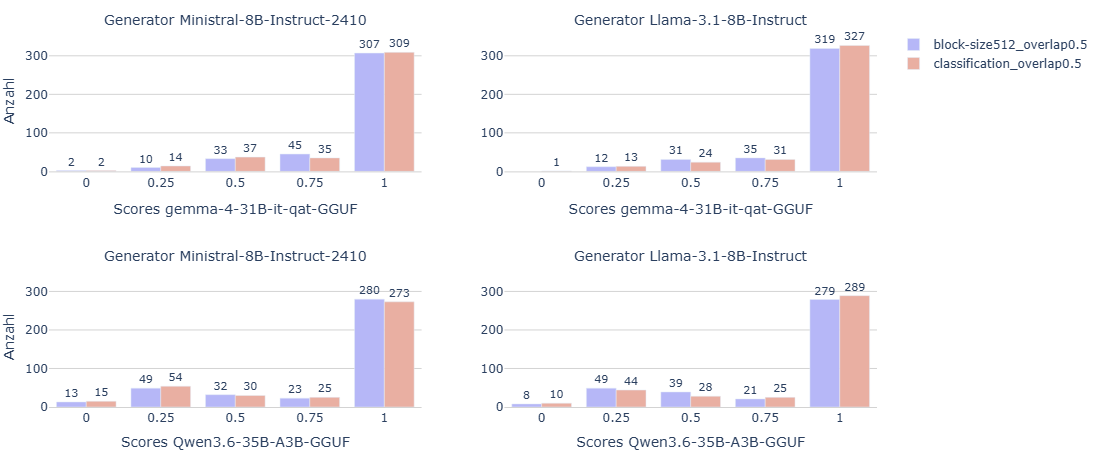

In [17]:
# Scores 1/3 und 2/3 ausschließen
# Daten nach generator_model, judge_model, retrieval gruppieren und scores zählen
df_group = (
    df.drop(df.loc[~df['scores'].isin([0.0, 0.25, 0.5, 0.75, 1.0])].index)
    .groupby(by=['retrieval', 'generator_model', 'judge_model'])['scores']
    .value_counts()
    .reset_index()
    #.sort_values(['generator_model', 'judge_model', 'retrieval', 'scores'])
)

fig = make_subplots(2, 2, subplot_titles=[f'Generator {m_g}' for m_j in df['judge_model'].unique() for m_g in df['generator_model'].unique()])

# Generator-Modell
for m_g in [0, 1]:
    model_name = config.models['generation'][m_g][config.models['generation'][m_g].index('/') + 1:]
    # Judge-Modell
    for m_j in [0, 1]:
        judge_model_name = config.models['judge'][m_j][config.models['judge'][m_j].index('/') + 1:config.models['judge'][m_j].index(':')]
        # Segmentierungsverfahren für Retrieval
        for r in range(len(retrieval)):
            y = df_group.loc[(df_group['judge_model'] == judge_model_name) & (df_group['generator_model'] == model_name) & (df_group['retrieval'] == retrieval[r]), 'count']
            # Bar-Plot hinzufügen
            fig.add_trace(go.Bar(
                x=df_group.loc[(df_group['judge_model'] == judge_model_name) & (df_group['generator_model'] == model_name) & (df_group['retrieval'] == retrieval[r]), 'scores'], 
                y=y,
                name=retrieval[r], 
                text=y,
                textposition='outside',#auto
                textfont={'size': 11},
                marker={'color': model_colors[r]},
                showlegend=False#, category_orders=category_orders
            ), row=m_j+1, col=m_g+1)

#fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey', title=yaxes['title'])
#fig.update_xaxes(showline=True, linewidth=1, linecolor='LightGrey', title=xaxes['title'])

# Achsen formatieren
fig['layout']['yaxis']['showgrid'] = True
fig['layout']['yaxis']['gridwidth'] = 1
fig['layout']['yaxis']['gridcolor'] = 'LightGrey'
fig['layout']['yaxis']['title']['text'] = 'Anzahl'
fig['layout']['yaxis']['range'] = [0, df_group['count'].max() + 40]

fig['layout']['xaxis']['showline'] = True
fig['layout']['xaxis']['linewidth'] = 1
fig['layout']['xaxis']['linecolor'] = 'LightGrey'
fig['layout']['xaxis']['title']['text'] = f'Scores {df['judge_model'].unique()[0]}'
#fig['layout']['xaxis']['tickvals'] = [0.0, 0.25, 1/3, 0.5, 2/3, 0.75, 1.0]
fig['layout']['xaxis']['dtick'] = 0.25

fig['layout']['yaxis2']['showgrid'] = True
fig['layout']['yaxis2']['gridwidth'] = 1
fig['layout']['yaxis2']['gridcolor'] = 'LightGrey'
fig['layout']['yaxis2']['range'] = [0, df_group['count'].max() + 40]

fig['layout']['xaxis2']['showline'] = True
fig['layout']['xaxis2']['linewidth'] = 1
fig['layout']['xaxis2']['linecolor'] = 'LightGrey'
fig['layout']['xaxis2']['title']['text'] = f'Scores {df['judge_model'].unique()[0]}'
fig['layout']['xaxis2']['dtick'] = 0.25

fig['layout']['yaxis3']['showgrid'] = True
fig['layout']['yaxis3']['gridwidth'] = 1
fig['layout']['yaxis3']['gridcolor'] = 'LightGrey'
fig['layout']['yaxis3']['title']['text'] = 'Anzahl'
fig['layout']['yaxis3']['range'] = [0, df_group['count'].max() + 40]

fig['layout']['xaxis3']['showline'] = True
fig['layout']['xaxis3']['linewidth'] = 1
fig['layout']['xaxis3']['linecolor'] = 'LightGrey'
fig['layout']['xaxis3']['title']['text'] = f'Scores {df['judge_model'].unique()[1]}'
fig['layout']['xaxis3']['dtick'] = 0.25

fig['layout']['yaxis4']['showgrid'] = True
fig['layout']['yaxis4']['gridwidth'] = 1
fig['layout']['yaxis4']['gridcolor'] = 'LightGrey'
fig['layout']['yaxis4']['range'] = [0, df_group['count'].max() + 40]

fig['layout']['xaxis4']['showline'] = True
fig['layout']['xaxis4']['linewidth'] = 1
fig['layout']['xaxis4']['linecolor'] = 'LightGrey'
fig['layout']['xaxis4']['title']['text'] = f'Scores {df['judge_model'].unique()[1]}'
fig['layout']['xaxis4']['dtick'] = 0.25

fig.update_layout(
    width=900,
    height=450,
    plot_bgcolor='rgba(255, 255, 255, 1.0)', 
    paper_bgcolor='rgba(255, 255, 255, 1.0)', 
    margin={'l':0, 'b':0, 'r':0, 't':30},
    #showlegend=True,
    boxmode='group',
    #boxgroupgap=0.0, 
    #boxgap=0.1
)

fig.update_annotations(font={'size': 14})#

fig['data'][0]['showlegend'] = True
fig['data'][1]['showlegend'] = True

#fig['layout']['yaxis']['title']['font']['size'] = 14
#fig['layout']['yaxis3']['title']['font']['size'] = 14

fig.show()

Für den überwiegenden Teil der Antworten beider Generator-Modelle wurde die volle Punktzahl vergeben, die Abbildung zeigt aber lediglich die Häufigkeiten der Scores für die verwendeten Segmentierungsverfahren und gibt keine Auskunft darüber, ob es sich jeweils um die Bewertung der gleichen Antworten handelt.

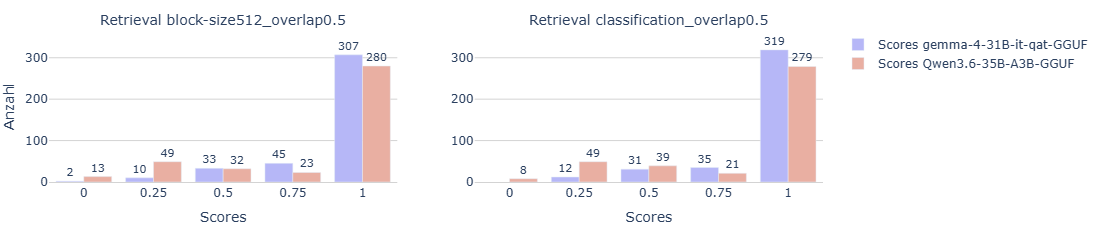

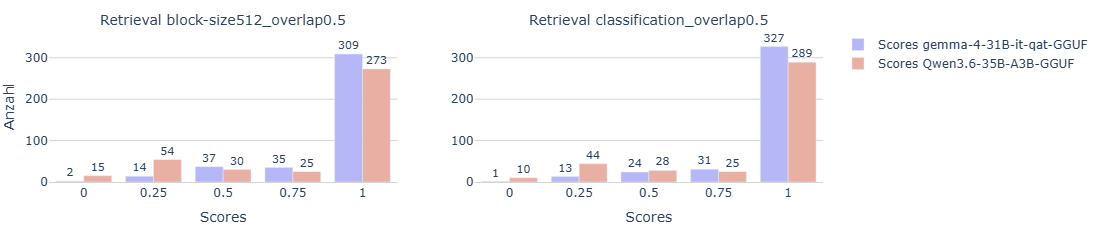

In [18]:
# Scores 1/3 und 2/3 ausschließen
# Daten nach generator_model, judge_model, retrieval gruppieren und scores zählen
df_group = (
    df.drop(df.loc[~df['scores'].isin([0.0, 0.25, 0.5, 0.75, 1.0])].index)
    .groupby(by=['retrieval', 'generator_model', 'judge_model'])['scores']
    .value_counts()
    .reset_index()
    #.sort_values(['generator_model', 'judge_model', 'retrieval', 'scores'])
)

# Segmentierungsverfahren für Retrieval
for r in range(len(retrieval)):
    fig = make_subplots(1, 2, subplot_titles=[f'Retrieval {retrieval[r]}' for r in range(len(retrieval))])
    # Generator-Modell
    for m_g in [0, 1]:
        model_name = config.models['generation'][m_g][config.models['generation'][m_g].index('/') + 1:]
        # Judge-Modell
        for m_j in [0, 1]:
            judge_model_name = config.models['judge'][m_j][config.models['judge'][m_j].index('/') + 1:config.models['judge'][m_j].index(':')]
            y = df_group.loc[(df_group['judge_model'] == judge_model_name) & (df_group['generator_model'] == model_name) & (df_group['retrieval'] == retrieval[r]), 'count']
            # Bar-Plot hinzufügen
            fig.add_trace(go.Bar(
                x=df_group.loc[(df_group['judge_model'] == judge_model_name) & (df_group['generator_model'] == model_name) & (df_group['retrieval'] == retrieval[r]), 'scores'], 
                y=y,
                name=f'Scores {judge_model_name}', 
                text=y,
                textposition='outside',#auto
                textfont={'size': 11},
                marker={'color': model_colors[m_j]},
                showlegend=False#, category_orders=category_orders
            ), row=1, col=m_g+1)

    #fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey', title=yaxes['title'])
    #fig.update_xaxes(showline=True, linewidth=1, linecolor='LightGrey', title=xaxes['title'])
    
    # Achsen formatieren
    fig['layout']['yaxis']['showgrid'] = True
    fig['layout']['yaxis']['gridwidth'] = 1
    fig['layout']['yaxis']['gridcolor'] = 'LightGrey'
    fig['layout']['yaxis']['title']['text'] = 'Anzahl'
    fig['layout']['yaxis']['range'] = [0, df_group['count'].max() + 40]
    
    fig['layout']['xaxis']['showline'] = True
    fig['layout']['xaxis']['linewidth'] = 1
    fig['layout']['xaxis']['linecolor'] = 'LightGrey'
    fig['layout']['xaxis']['title']['text'] = 'Scores'
    #fig['layout']['xaxis']['tickvals'] = [0.0, 0.25, 1/3, 0.5, 2/3, 0.75, 1.0]
    fig['layout']['xaxis']['dtick'] = 0.25
    
    fig['layout']['yaxis2']['showgrid'] = True
    fig['layout']['yaxis2']['gridwidth'] = 1
    fig['layout']['yaxis2']['gridcolor'] = 'LightGrey'
    fig['layout']['yaxis2']['range'] = [0, df_group['count'].max() + 40]
    
    fig['layout']['xaxis2']['showline'] = True
    fig['layout']['xaxis2']['linewidth'] = 1
    fig['layout']['xaxis2']['linecolor'] = 'LightGrey'
    fig['layout']['xaxis2']['title']['text'] = 'Scores'
    fig['layout']['xaxis2']['dtick'] = 0.25
    
    fig.update_layout(
        width=900,
        height=225,
        plot_bgcolor='rgba(255, 255, 255, 1.0)', 
        paper_bgcolor='rgba(255, 255, 255, 1.0)', 
        margin={'l':0, 'b':0, 'r':0, 't':30},
        #showlegend=True,
        boxmode='group',
        #boxgroupgap=0.0, 
        #boxgap=0.1
    )
    
    fig.update_annotations(font={'size': 14})#
    
    fig['data'][0]['showlegend'] = True
    fig['data'][1]['showlegend'] = True
    
    #fig['layout']['yaxis']['title']['font']['size'] = 14
    #fig['layout']['yaxis3']['title']['font']['size'] = 14
    
    fig.show()

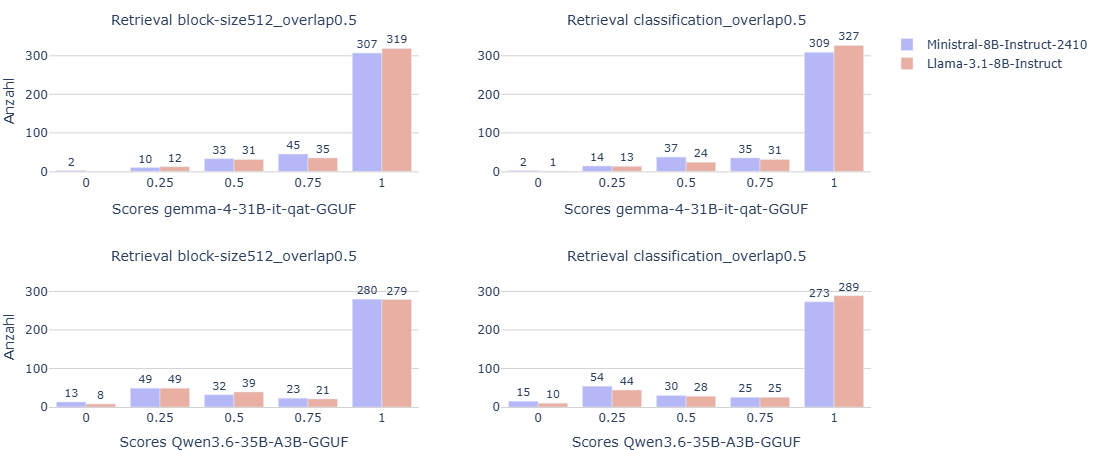

In [19]:
# Scores 1/3 und 2/3 ausschließen
# Daten nach generator_model, judge_model, retrieval gruppieren und scores zählen
df_group = (
    df.drop(df.loc[~df['scores'].isin([0.0, 0.25, 0.5, 0.75, 1.0])].index)
    .groupby(by=['retrieval', 'generator_model', 'judge_model'])['scores']
    .value_counts()
    .reset_index()
    #.sort_values(['generator_model', 'judge_model', 'retrieval', 'scores'])
)

fig = make_subplots(2, 2, subplot_titles=[f'Retrieval {retrieval[r]}' for m_j in df['judge_model'].unique() for r in range(len(retrieval))])

# Segmentierungsverfahren für Retrieval
for r in range(len(retrieval)):
    # Judge-Modell
    for m_j in [0, 1]:
        judge_model_name = config.models['judge'][m_j][config.models['judge'][m_j].index('/') + 1:config.models['judge'][m_j].index(':')]
        # Generator-Modell
        for m_g in [0, 1]:
            model_name = config.models['generation'][m_g][config.models['generation'][m_g].index('/') + 1:]
            y = df_group.loc[(df_group['judge_model'] == judge_model_name) & (df_group['generator_model'] == model_name) & (df_group['retrieval'] == retrieval[r]), 'count']
            # Bar-Plot hinzufügen
            fig.add_trace(go.Bar(
                x=df_group.loc[(df_group['judge_model'] == judge_model_name) & (df_group['generator_model'] == model_name) & (df_group['retrieval'] == retrieval[r]), 'scores'], 
                y=y,
                name=model_name, 
                text=y,
                textposition='outside',#auto
                textfont={'size': 11},
                marker={'color': model_colors[m_g]},
                showlegend=False#, category_orders=category_orders
            ), row=m_j+1, col=r+1)

#fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey', title=yaxes['title'])
#fig.update_xaxes(showline=True, linewidth=1, linecolor='LightGrey', title=xaxes['title'])

# Achsen formatieren
fig['layout']['yaxis']['showgrid'] = True
fig['layout']['yaxis']['gridwidth'] = 1
fig['layout']['yaxis']['gridcolor'] = 'LightGrey'
fig['layout']['yaxis']['title']['text'] = 'Anzahl'
fig['layout']['yaxis']['range'] = [0, df_group['count'].max() + 40]

fig['layout']['xaxis']['showline'] = True
fig['layout']['xaxis']['linewidth'] = 1
fig['layout']['xaxis']['linecolor'] = 'LightGrey'
fig['layout']['xaxis']['title']['text'] = f'Scores {df['judge_model'].unique()[0]}'
#fig['layout']['xaxis']['tickvals'] = [0.0, 0.25, 1/3, 0.5, 2/3, 0.75, 1.0]
fig['layout']['xaxis']['dtick'] = 0.25

fig['layout']['yaxis2']['showgrid'] = True
fig['layout']['yaxis2']['gridwidth'] = 1
fig['layout']['yaxis2']['gridcolor'] = 'LightGrey'
fig['layout']['yaxis2']['range'] = [0, df_group['count'].max() + 40]

fig['layout']['xaxis2']['showline'] = True
fig['layout']['xaxis2']['linewidth'] = 1
fig['layout']['xaxis2']['linecolor'] = 'LightGrey'
fig['layout']['xaxis2']['title']['text'] = f'Scores {df['judge_model'].unique()[0]}'
fig['layout']['xaxis2']['dtick'] = 0.25

fig['layout']['yaxis3']['showgrid'] = True
fig['layout']['yaxis3']['gridwidth'] = 1
fig['layout']['yaxis3']['gridcolor'] = 'LightGrey'
fig['layout']['yaxis3']['title']['text'] = 'Anzahl'
fig['layout']['yaxis3']['range'] = [0, df_group['count'].max() + 40]

fig['layout']['xaxis3']['showline'] = True
fig['layout']['xaxis3']['linewidth'] = 1
fig['layout']['xaxis3']['linecolor'] = 'LightGrey'
fig['layout']['xaxis3']['title']['text'] = f'Scores {df['judge_model'].unique()[1]}'
fig['layout']['xaxis3']['dtick'] = 0.25

fig['layout']['yaxis4']['showgrid'] = True
fig['layout']['yaxis4']['gridwidth'] = 1
fig['layout']['yaxis4']['gridcolor'] = 'LightGrey'
fig['layout']['yaxis4']['range'] = [0, df_group['count'].max() + 40]

fig['layout']['xaxis4']['showline'] = True
fig['layout']['xaxis4']['linewidth'] = 1
fig['layout']['xaxis4']['linecolor'] = 'LightGrey'
fig['layout']['xaxis4']['title']['text'] = f'Scores {df['judge_model'].unique()[1]}'
fig['layout']['xaxis4']['dtick'] = 0.25

fig.update_layout(
    width=900,
    height=450,
    plot_bgcolor='rgba(255, 255, 255, 1.0)', 
    paper_bgcolor='rgba(255, 255, 255, 1.0)', 
    margin={'l':0, 'b':0, 'r':0, 't':30},
    #showlegend=True,
    boxmode='group',
    #boxgroupgap=0.0, 
    #boxgap=0.1
)

fig.update_annotations(font={'size': 14})#

fig['data'][0]['showlegend'] = True
fig['data'][1]['showlegend'] = True

#fig['layout']['yaxis']['title']['font']['size'] = 14
#fig['layout']['yaxis3']['title']['font']['size'] = 14

fig.show()

### Heatmap Judge-Scores

Gegenüberstellung und Korrelation der Bewertungen durch Judge-LLMs für Generator-LLMs und Segmentierungsverfahren

Modell: Ministral-8B-Instruct-2410

Retrieval: block-size512_overlap0.5

spearmanr: SignificanceResult(statistic=np.float64(0.7300216607813168), pvalue=np.float64(2.7651496505863966e-67))
kendalltau: SignificanceResult(statistic=np.float64(0.6906263601980798), pvalue=np.float64(1.8804726796149347e-50))

Retrieval: classification_overlap0.5

spearmanr: SignificanceResult(statistic=np.float64(0.7363276116623573), pvalue=np.float64(5.283245225799211e-69))
kendalltau: SignificanceResult(statistic=np.float64(0.6933871589593746), pvalue=np.float64(3.0914032090690907e-51))



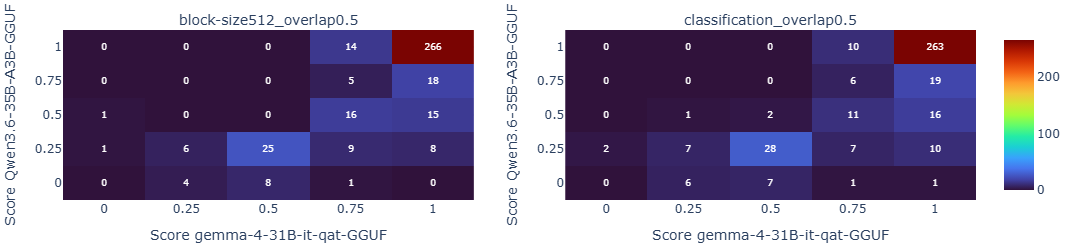

Modell: Llama-3.1-8B-Instruct

Retrieval: block-size512_overlap0.5

spearmanr: SignificanceResult(statistic=np.float64(0.7434765203340836), pvalue=np.float64(5.1701806938872605e-71))
kendalltau: SignificanceResult(statistic=np.float64(0.7016395655713248), pvalue=np.float64(1.662510856937061e-51))

Retrieval: classification_overlap0.5

spearmanr: SignificanceResult(statistic=np.float64(0.6631411651865616), pvalue=np.float64(1.2157557664789103e-51))
kendalltau: SignificanceResult(statistic=np.float64(0.6295968292643647), pvalue=np.float64(1.7481546340258898e-41))



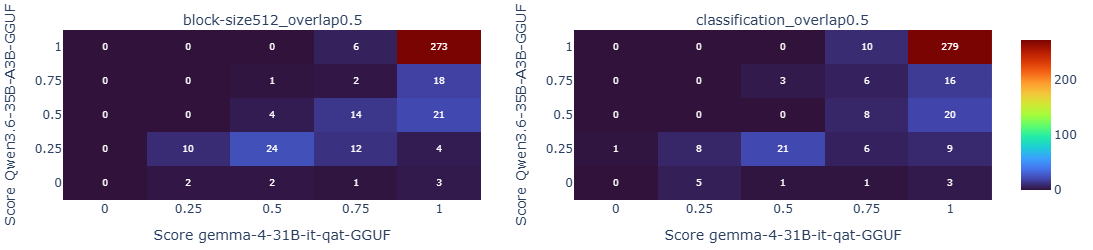

In [20]:
#df_select = df.loc[df['answer_word_count_diff'] > 48]
#df_select = df.loc[df['type'] == 'extractive']#extractive, abstractive
df_select = df

# Judge-LLMs
judge_model_name0 = config.models['judge'][0][config.models['judge'][0].index('/') + 1:config.models['judge'][0].index(':')]
judge_model_name1 = config.models['judge'][1][config.models['judge'][1].index('/') + 1:config.models['judge'][1].index(':')]

#coordinates = np.arange(start=0.0, stop=1.25, step=0.25)
coordinates = np.array(range(5)) / 4

# Generator-Modelle
for m_g in [0, 1]:
    fig = make_subplots(1, 2, subplot_titles=[r for r in retrieval])#
    model_name = config.models['generation'][m_g][config.models['generation'][m_g].index('/') + 1:]
    print(f'Modell: {model_name}\n')
    # Segmentierungsverfahren für Retrieval
    for r in [0, 1]:
        # Ergebnisse der Evaluierung für beide Judge-LLMs laden
        #result0 = EvalResult.from_experiment(f'./rag-eval/{model_name}_retrieval_{retrieval[r]}_{judge_model_name0}')
        #result1 = EvalResult.from_experiment(f'./rag-eval/{model_name}_retrieval_{retrieval[r]}_{judge_model_name1}')

        # Bewertungsscores
        #x = np.array([item.report.score * 4 for item in result0.item_results if item.report.score is not None], dtype=int)
        #y = np.array([item.report.score * 4 for item in result1.item_results if item.report.score is not None], dtype=int)
        
        # Bewertungsscores aus Dataframe
        x = np.array(df_select.loc[(df_select['generator_model'] == model_name) & (df_select['judge_model'] == judge_model_name0) & (df_select['retrieval'] == retrieval[r])]['scores'] * 4, dtype=int)#.sort_values(['answer_index'])
        y = np.array(df_select.loc[(df_select['generator_model'] == model_name) & (df_select['judge_model'] == judge_model_name1) & (df_select['retrieval'] == retrieval[r])]['scores'] * 4, dtype=int)

        print(f'Retrieval: {retrieval[r]}\n')
        print(f'spearmanr: {stats.spearmanr(x, y)}')
        print(f'kendalltau: {stats.kendalltau(x, y)}')
        print('')

        # Matrix für Scores zwischen Judge-LLMs erstellen
        matrix = np.zeros((5, 5), dtype=int)
        np.add.at(matrix, (y, x), 1)

        # Heatmap hinzufügen
        fig.add_trace(go.Heatmap(
            x=coordinates,
            y=coordinates,
            z=matrix,
            colorscale='turbo',
            text=matrix,
            texttemplate='%{z}',#text
            textfont={'size': 9},
            #name=f'{model_name} {retrieval[r]}',
            showscale=False,
            hovertemplate=judge_model_name0 + ": %{x}<br>" + judge_model_name1 + ": %{y}<br />Anzahl: %{z}"
        ), row=1, col=r+1)

    fig.update_annotations(font={'size': 14})
    
    fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey', title=f'Score {judge_model_name1}', dtick=0.25)#, range=[0.0, 1.0]
    fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey', title=f'Score {judge_model_name0}', dtick=0.25)
    
    fig.update_layout(
        width=900,
        height=250,
        plot_bgcolor='rgba(255, 255, 255, 1.0)', 
        paper_bgcolor='rgba(255, 255, 255, 1.0)', 
        margin={'l':10, 'b':10, 'r':10, 't':30},
        #title=model_name,
        showlegend=False
    )

    fig.update_traces(row=1, col=1, showscale=True)

    #fig['layout']['yaxis']['title']['text'] = f'Score {judge_model_name1}'
    
    fig.show()

| Generator-Modell | Retrieval | Spearman | Kendall’s tau |
| - | - | - | - |
| Ministral-8B-Instruct-2410 | block-size512_overlap0.5 | 0.7300216607813168 | 0.6906263601980798 |
| Ministral-8B-Instruct-2410 | classification_overlap0.5 | 0.7363276116623573 | 0.6933871589593746 |
| Llama-3.1-8B-Instruct | block-size512_overlap0.5 | 0.7434765203340836 | 0.7016395655713248 |
| Llama-3.1-8B-Instruct | classification_overlap0.5 | 0.6631411651865616 | 0.6295968292643647 |

Der Pearson-Korrelationskoeffizient misst den Zusammenhang zwischen zwei stetigen Variablen, für die Messung des Zusammenhangs zwischen ordianalskalierten Variablen ist ebenfalls der Spearman-Korrelationskoeffizient oder der Kendall’s Tau Rangkorrelationskoeffizient, welcher den monotonen Zusammenhang über die Rangordung der Wertpaare vergleicht, geeignet.

Die Korrelation zwischen den Bewertungen der beiden Judge-Modelle für die Antworten des Generator-LLMs Ministral-8B-Instruct-2410 ist für beide Segmentierungsverfahren mit einem Spearman-Korrelationskoeffizienten von 0.73 und 0.7362 nahezu gleich. Für das Modell Llama-3.1-8B-Instruct und Segmentierungsverfahren block-size512\_overlap0.5 ist sie mit 0.7435 gegenüber classification\_overlap0.5 mit 0.6631 höher. Insgesamt besteht ein starker positiver Zusammenhang zwischen den Bewertungen und die Antworten wurden durch die Judge-Modelle relativ ähnlich bewertet.

### Heatmap Retrieval-Scores

Gegenüberstellung und Korrelation der Bewertungen nach Segmentierungsverfahren für beide Judge- und Generator-Modelle.

Modell: Ministral-8B-Instruct-2410

Judge-Modell: gemma-4-31B-it-qat-GGUF

spearmanr: SignificanceResult(statistic=np.float64(0.44094837630311046), pvalue=np.float64(2.566697815018071e-20))
kendalltau: SignificanceResult(statistic=np.float64(0.4193406687077506), pvalue=np.float64(4.229233320412506e-19))

Judge-Modell: Qwen3.6-35B-A3B-GGUF

spearmanr: SignificanceResult(statistic=np.float64(0.46167054083492864), pvalue=np.float64(2.3706600159343662e-22))
kendalltau: SignificanceResult(statistic=np.float64(0.4234480681155439), pvalue=np.float64(9.765939346096859e-21))



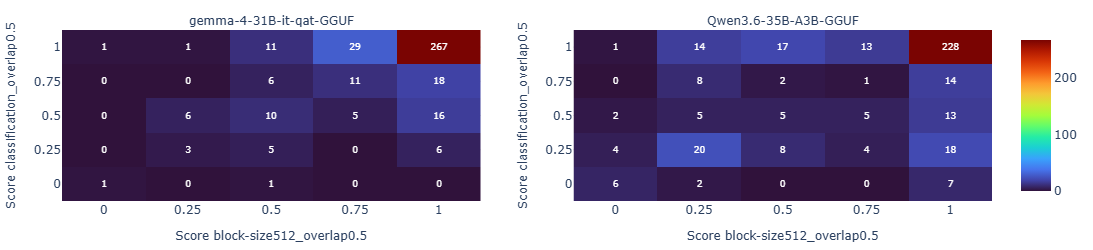

Modell: Llama-3.1-8B-Instruct

Judge-Modell: gemma-4-31B-it-qat-GGUF

spearmanr: SignificanceResult(statistic=np.float64(0.5258104779190705), pvalue=np.float64(1.3231161547915608e-29))
kendalltau: SignificanceResult(statistic=np.float64(0.5062393677110121), pvalue=np.float64(1.40703577340072e-26))

Judge-Modell: Qwen3.6-35B-A3B-GGUF

spearmanr: SignificanceResult(statistic=np.float64(0.490704026982296), pvalue=np.float64(1.9080626289956946e-25))
kendalltau: SignificanceResult(statistic=np.float64(0.4519058756029208), pvalue=np.float64(4.745465313750583e-23))



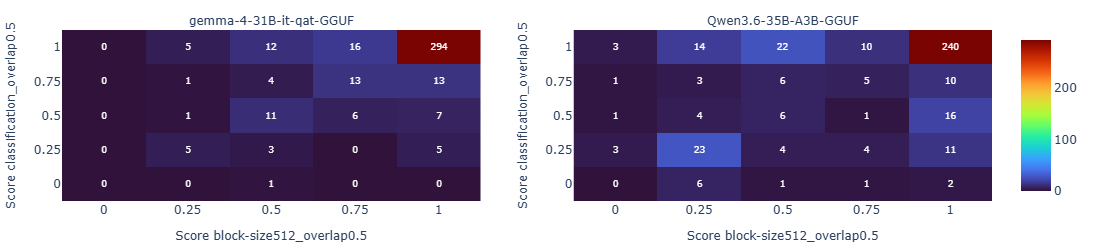

In [21]:
# Dictionary für Werte der Übereinstimmung der Bewertungen zwischen Segmentierungsverfahren
retrival_ratings = {'generator_model': [], 'judge_model': [], '0.0': [], '0.25': [], '0.5': [], '0.75': [], '1.0': []}

#coordinates = np.arange(start=0.0, stop=1.25, step=0.25)
coordinates = np.array(range(5)) / 4

# Generator-Modelle
for m_g in [0, 1]:
    fig = make_subplots(1, 2, subplot_titles=[m_j[m_j.index('/') + 1: m_j.index(':')] for m_j in config.models['judge']])#
    model_name = config.models['generation'][m_g][config.models['generation'][m_g].index('/') + 1:]
    print(f'Modell: {model_name}\n')
    # Judge-LLMs
    for m_j in [0, 1]:
        judge_model_name = config.models['judge'][m_j][config.models['judge'][m_j].index('/') + 1: config.models['judge'][m_j].index(':')]
        
        # Bewertungsscores aus Dataframe
        x = np.array(df.loc[(df['generator_model'] == model_name) & (df['judge_model'] == judge_model_name) & (df['retrieval'] == retrieval[0])]['scores'] * 4, dtype=int)
        y = np.array(df.loc[(df['generator_model'] == model_name) & (df['judge_model'] == judge_model_name) & (df['retrieval'] == retrieval[1])]['scores'] * 4, dtype=int)

        print(f'Judge-Modell: {judge_model_name}\n')
        print(f'spearmanr: {stats.spearmanr(x, y)}')
        print(f'kendalltau: {stats.kendalltau(x, y)}')
        print('')

        # Wilcoxon-Vorzeichen-Rang-Test 
        #w_stat, p_wert = stats.wilcoxon(x, y)
        #print('w-test')
        #print(f'w-statistic: {w_stat}, p-value: {p_val}')
        #print('')

        # Matrix für Scores zwischen Judge-LLMs erstellen
        matrix = np.zeros((5, 5), dtype=int)
        np.add.at(matrix, (y, x), 1)

        retrival_ratings['generator_model'].append(model_name)
        retrival_ratings['judge_model'].append(judge_model_name)
        retrival_ratings['0.0'].append(matrix[0][0])
        retrival_ratings['0.25'].append(matrix[1][1])
        retrival_ratings['0.5'].append(matrix[2][2])
        retrival_ratings['0.75'].append(matrix[3][3])
        retrival_ratings['1.0'].append(matrix[4][4])

        # Heatmap hinzufügen
        fig.add_trace(go.Heatmap(
            x=coordinates,
            y=coordinates,
            z=matrix,
            colorscale='turbo',
            text=matrix,
            texttemplate="%{text}",
            textfont={'size': 9},
            #name=f'{model_name} {judge_model_name}',
            showscale=False,
            hovertemplate=retrieval[0] + ": %{x}<br>" + retrieval[1] + ": %{y}<br />Anzahl: %{z}"
        ), row=1, col=m_j+1)

    fig.update_annotations(font={'size': 14})
    
    fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey', title={'text': f'Score {retrieval[1]}', 'font':{'size': 12}}, dtick=0.25)#, range=[0.0, 1.0]
    fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey', title={'text': f'Score {retrieval[0]}', 'font':{'size': 12}}, dtick=0.25)
    
    fig.update_layout(
        width=900,
        height=250,
        plot_bgcolor='rgba(255, 255, 255, 1.0)', 
        paper_bgcolor='rgba(255, 255, 255, 1.0)', 
        margin={'l':10, 'b':10, 'r':10, 't':30},
        #title=model_name,
        showlegend=False
    )

    fig.update_traces(row=1, col=1, showscale=True)
    fig.update_annotations(font={'size': 12})#

    #fig['layout']['yaxis']['title']['text'] = f'Score {judge_model_name1}'
    
    fig.show()

df_retrival_ratings = pd.DataFrame.from_dict(retrival_ratings)

| Generator-Modell | Judge-Modell | Spearman | Kendall’s tau |
| - | - | - | - |
| Ministral-8B-Instruct-2410 | gemma-4-31B-it-qat-GGUF | 0.44094837630311046 | 0.4193406687077506 |
| Ministral-8B-Instruct-2410 | Qwen3.6-35B-A3B-GGUF | 0.46167054083492864 | 0.4234480681155439 |
| Llama-3.1-8B-Instruct | gemma-4-31B-it-qat-GGUF | 0.5258104779190705 | 0.5062393677110121 |
| Llama-3.1-8B-Instruct | Qwen3.6-35B-A3B-GGUF | 0.490704026982296 | 0.4519058756029208 |

Bezogen auf das eingesetzte Segmentierungsverfahren wurden die Antworten durch die Judge-Modelle in Teilen sehr unterschiedlich bewertet. Die unter Verwendung eines Segmentierungsverfahrens erzeugten Antworten eines Generator-Modells wurden durch ein Judge-Modell höher und die unter Verwendung des jeweils anderen Verfahren erzeugten Antworten durch das gleiche Judge-Modell niedriger bewertet.

Für die Antworten des Generator-Modells Ministral-8B-Instruct-2410 ist die Korrelation der Bewertungen durch beide Judge-Modelle zwischen den Segmentierungsverfahren mit einem Spearman-Korrelationskoeffizienten von 0.4409 und 0.4617 gegenüber Llama-3.1-8B-Instruct mit 0.5258 und 0.4907 geringer.

Insgesamt besteht ein eher schwacher positiver Zusammenhang und die Korrelationskoeffizient belegen die bereits über die Heatmap erkennbaren unterschiedlichen Bewertungen.

### Beispiel Bewertung

Prüfung einer Modell-Antwort mit unterschiedlich hohen Bewertungen durch Judge-Modelle

In [22]:
index = queries_text_text_table_select.iloc[3].name

get_sample(index=index, model_select=1, judge_model_select=1, retrieval_select=0)

#'d25337d2-a377-45dd-ba97-f50a04ed6baf'

index: c16f4e40-c8bd-4817-b4e8-3926c6544bf8
---
generator model: Llama-3.1-8B-Instruct
---
judge model: Qwen3.6-35B-A3B-GGUF
---
retrieval: block-size512_overlap0.5
---
query

What is the relationship between the size of an alphabet and the growth rate of square-free circular words?
---
answer reference

The growth rate of square-free circular words is similar to that of square-free words when the alphabet size is at least 5. A constant $C$, which varies with the alphabet size, bounds this relationship.
---
answer model

According to the provided information, the growth rate of square-free circular words is related to the size of the alphabet as follows:

- For an alphabet of size at least 5, the growth rate of square-free circular words is the same as that of square-free words, which is approximately 1.30176 (given in [18]).
- The growth rate for the set of ternary square-free circular words is approximately 1.3, as stated in [17, Proposition 1].
- The growth rate of square-free circu

In [23]:
index = queries_text_text_table_select.iloc[3].name

get_sample(index=index, model_select=1, judge_model_select=1, retrieval_select=1)

index: c16f4e40-c8bd-4817-b4e8-3926c6544bf8
---
generator model: Llama-3.1-8B-Instruct
---
judge model: Qwen3.6-35B-A3B-GGUF
---
retrieval: classification_overlap0.5
---
query

What is the relationship between the size of an alphabet and the growth rate of square-free circular words?
---
answer reference

The growth rate of square-free circular words is similar to that of square-free words when the alphabet size is at least 5. A constant $C$, which varies with the alphabet size, bounds this relationship.
---
answer model

According to Theorem 14, if there exists β ą 1 such that |Ln`1pA, 2q| ě β|LnpA, 2q| for all n ě 0 and let

C – 1 ´ 1 ` β pβ ´ 1q2 ą 0 ,

then for all n ě 0, |LnpA, 2q| ě |

˝LnpA, 2q| ě C ¨ |LnpA, 2q| .

This implies that the growth rate of square-free circular words is the same as the growth rate of square-free words, which is given by αpA, 2q. Corollary 15 states that if A is an alphabet with |A| ě 5, then C ą 0 and | ˝LnpA, 2q| ě C|LnpA, 2q|.

Therefore, the size o

In [24]:
#
pdf_doc_id = qrels.loc[queries_text_text_table_select.iloc[3].name, 'doc_id']
print(pdf_doc_id)
pdf_df = pq.read_table(f'{config.dataset["path"]}pdfs_df/{pdf_doc_id}.parquet').to_pandas()
print('\n\n'.join(pdf_df['text']))

2410.19654v2
An explicit condition for boundedly supermultiplicative subshifts Vuong Bui∗† Matthieu Rosenfeld∗

Abstract

We study some properties of the growth rate of LpA, Fq, that is, the language of words over the alphabet A avoiding the set of forbidden factors F. We first provide a sufficient condition on F and A for the growth of LpA, Fq to be boundedly supermultiplicative. That is, there exist constants C ą 0 and α ě 0, such that for all n, the number of words of length n in LpA, Fq is between αn and Cαn. In some settings, our condition provides a way to compute C, which implies that α, the growth rate of the language, is also computable whenever our condition holds. We also apply our technique to the specific setting of power-free words where the argument can be slightly refined to provide better bounds. Finally, we apply a similar idea to F-free circular words and in particular we make progress toward a conjecture of Shur about the number of square-free circular words.

1 Int